# 03 — Model training on real data

The four-stage narrative, four models, 450 real samples.

| Stage | Layout | Scaling | Grid | What it isolates |
|-------|--------|---------|------|------------------|
| 1. reproduce | original | original | original | The thesis itself |
| 2. layout fix | fixed | original | original | The C-order reshape bug |
| 3. scale fix | fixed | principled | original | The scaler-before-split leak |
| 4. regrid | fixed | principled | extended | The miscalibrated SVR and GPR grids |

Random forest and XGBoost stop at stage 3: their grids are layout-agnostic so a hypothetical stage 4 would be identical.

All metric cells report `rmse_scaled` (for direct comparison with the thesis tables) and `rmse_hours` (the true-scale view). R2 is invariant to linear rescaling of the target and is reported once.

Runtime: roughly 10 to 15 minutes on CPU, dominated by the Random Forest grid search.


In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone

from solder_reliability import find_repo_root
from solder_reliability.data_prep import load_raw
from solder_reliability import train, viz

os.chdir(find_repo_root(Path.cwd()))

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)

## 1. Load the 450 real samples in both layouts

Stage 1 uses the original layout, stages 2 through 4 use the fixed layout.

In [2]:
RAW_DIR = Path('data/raw')
PARTIALS_DIR = Path('results/partials')
PARTIALS_DIR.mkdir(parents=True, exist_ok=True)

X_fixed, y_fixed = load_raw(RAW_DIR, layout='fixed')
X_orig,  y_orig  = load_raw(RAW_DIR, layout='original')

print('fixed    ', X_fixed.shape, y_fixed.shape)
print('original ', X_orig.shape,  y_orig.shape)

fixed     (450, 24) (450,)
original  (450, 24) (450,)


## 2. Run the four stages

Every model runs through its applicable stages via `train.run_all`. GridSearchCV is done per stage. Cross-validation uses 3 folds, matching the thesis. The fitted best estimator per (model, stage) is returned for the learning-curve and prediction cells below.

Runtime warning: the Random Forest grid has 81 parameter combinations times 3 folds. Expect 10 to 15 minutes total.

In [3]:
results_real, fitted_real = train.run_all(
    {'fixed': (X_fixed, y_fixed), 'original': (X_orig, y_orig)},
    verbose=True,
)

gpr            1. reproduce ... 

r2=+0.0773  test_rmse_hours=617h
gpr            2. layout fix ... 

C:\Users\Dell\.conda\envs\solder-reliability\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dell\.conda\envs\solder-reliability\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dell\.conda\envs\solder-reliability\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dell\.conda\envs\solde

r2=+0.5182  test_rmse_hours=446h
gpr            3. scale fix ... 

C:\Users\Dell\.conda\envs\solder-reliability\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dell\.conda\envs\solder-reliability\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dell\.conda\envs\solder-reliability\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dell\.conda\envs\solde

...

r2=+0.3707  test_rmse_hours=509h


xgboost        1. reproduce ... 

r2=+0.0283  test_rmse_hours=633h
xgboost        2. layout fix ... 

r2=+0.7278  test_rmse_hours=335h
xgboost        3. scale fix ... 

r2=+0.7278  test_rmse_hours=335h


In [4]:
summary_cols = [
    'model', 'stage', 'layout', 'scale_strategy', 'grid',
    'r2',
    'test_rmse_scaled', 'test_rmse_hours',
    'cv_rmse_scaled',   'cv_rmse_hours',
    'target_spread_hours',
]
display_df = results_real[summary_cols].copy()
display_df['r2']               = display_df['r2'].round(4)
display_df['test_rmse_scaled'] = display_df['test_rmse_scaled'].round(4)
display_df['test_rmse_hours']  = display_df['test_rmse_hours'].round(0).astype(int)
display_df['cv_rmse_scaled']   = display_df['cv_rmse_scaled'].round(4)
display_df['cv_rmse_hours']    = display_df['cv_rmse_hours'].round(0).astype(int)
display_df['target_spread_hours'] = display_df['target_spread_hours'].round(0).astype(int)
display_df

,model,stage,layout,scale_strategy,grid,r2,test_rmse_scaled,test_rmse_hours,cv_rmse_scaled,cv_rmse_hours,target_spread_hours
0,gpr,1. reproduce,original,original,original,0.0773,0.0928,617,0.0869,577,6643
1,gpr,2. layout fix,fixed,original,original,0.5182,0.0671,446,0.0628,417,6643
2,gpr,3. scale fix,fixed,principled,original,0.5178,0.0671,446,0.0630,418,6643
3,gpr,4. regrid,fixed,principled,extended,0.5199,0.0670,445,0.0609,404,6643
4,random_forest,1. reproduce,original,original,original,0.0924,0.0921,612,0.0856,569,6643
5,random_forest,2. layout fix,fixed,original,original,0.7504,0.0483,321,0.0378,251,6643
6,random_forest,3. scale fix,fixed,principled,original,0.7496,0.0484,321,0.0378,251,6643
7,svr,1. reproduce,original,original,original,0.1126,0.0911,605,0.0849,564,6643
8,svr,2. layout fix,fixed,original,original,0.3731,0.0765,508,0.0709,471,6643
9,svr,3. scale fix,fixed,principled,original,0.3741,0.0765,508,0.0709,471,6643


In [5]:
# Save partial metrics for notebook 5
out = PARTIALS_DIR / 'real.csv'
results_real.to_csv(out, index=False)
print('wrote', out)
print('shape', results_real.shape)
print()
print('best_params per (model, stage):')
for _, r in results_real.iterrows():
    print(f'  {r["model"]:14s} {r["stage"]:14s} {r["best_params"]}')

wrote results\partials\real.csv
shape (14, 16)

best_params per (model, stage):
  gpr            1. reproduce   {'alpha': 0.01, 'kernel': RBF(length_scale=1)}
  gpr            2. layout fix  {'alpha': 0.001, 'kernel': RBF(length_scale=1)}
  gpr            3. scale fix   {'alpha': 0.001, 'kernel': RBF(length_scale=1)}
  gpr            4. regrid      {'alpha': 1e-06, 'kernel': 1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=0.001)}
  random_forest  1. reproduce   {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
  random_forest  2. layout fix  {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
  random_forest  3. scale fix   {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
  svr            1. reproduce   {'C': 1.0, 'gamma': 1.0, 'kernel': 'rbf'}
  svr            2. layout fix  {'C': 10.0, 'gamma': 0.1, 'kernel': 'rbf'}
  svr            3. scale fix   {'C': 10.0, 'gamma': 0.1

## 3. Reading the summary table

Two stories run in parallel.

**Stage 1 to stage 2: the layout fix.** This is the headline. Model trained on the correct per-sample layout should show a large R2 delta against stage 1.

**Stage 2 to stage 3: the scaling fix.** Small, but principled. The scaler in stage 2 leaked test statistics into the training fit; stage 3 does not.

**Stage 3 to stage 4: the regrid (SVR and GPR only).** Their original grids were tuned against a matrix that no longer exists.

On real data, no model is expected to beat a horizontal line. That is the honest starting point. The synthetic track in notebook 4 is where R2 becomes meaningfully positive.

## 4. Learning curves per model

Learning curve for each model at its best stage. Uses the tuned estimator from the stage with the highest R2. RMSE on the axis is in scaled units, as in the thesis.

C:\Users\Dell\.conda\envs\solder-reliability\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dell\.conda\envs\solder-reliability\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dell\.conda\envs\solder-reliability\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dell\.co

C:\Users\Dell\.conda\envs\solder-reliability\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dell\.conda\envs\solder-reliability\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dell\.conda\envs\solder-reliability\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dell\.co

C:\Users\Dell\.conda\envs\solder-reliability\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dell\.conda\envs\solder-reliability\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\Dell\.conda\envs\solder-reliability\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dell\.conda\envs\solder-reliability\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\Dell\.conda\envs\solder-reliability\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dell\.conda\envs\solder-reliability\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\Dell\.conda\envs\solder-reliability\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dell\.conda\envs\solder-reliability\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


C:\Users\Dell\.conda\envs\solder-reliability\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dell\.conda\envs\solder-reliability\lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


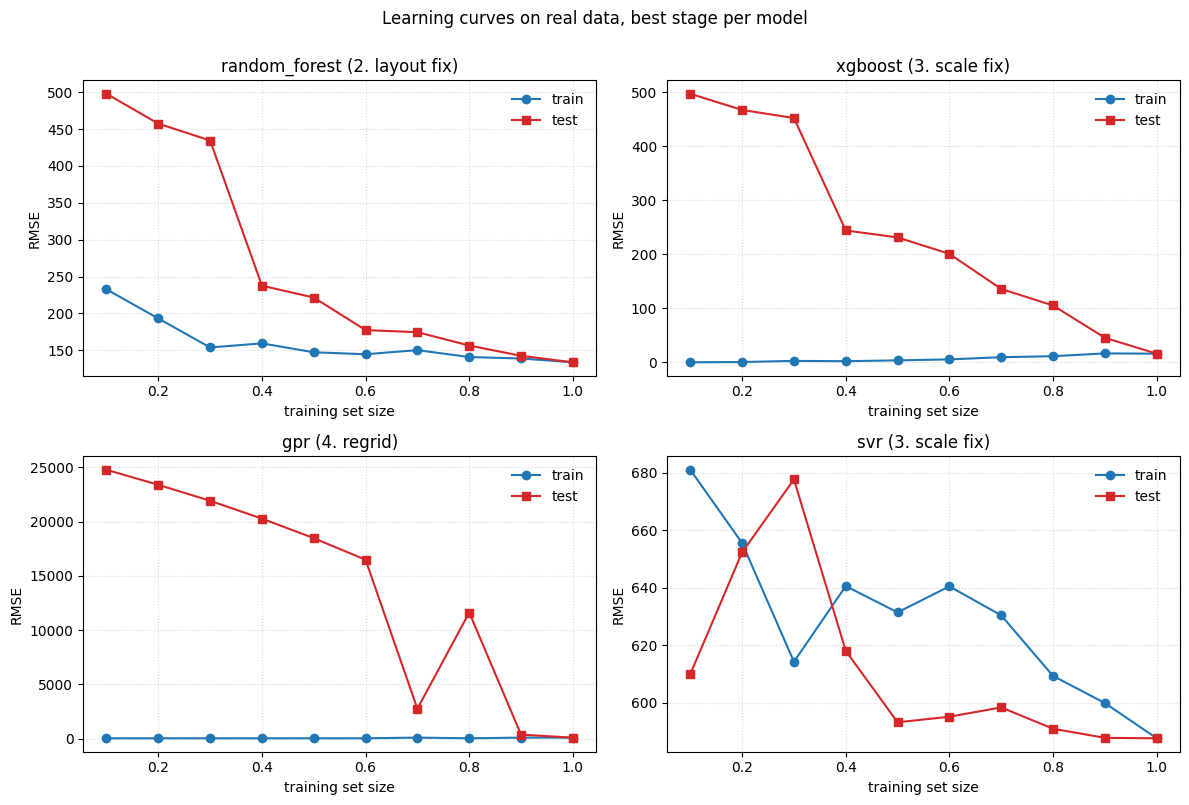

saved reports\figures\real_learning_curves.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

best_stage_per_model = (
    results_real.sort_values('r2', ascending=False)
    .groupby('model', sort=False)
    .first()
    .reset_index()
)

for ax, (_, row) in zip(axes, best_stage_per_model.iterrows()):
    model_name = row['model']
    stage_name = row['stage']
    est = fitted_real[(model_name, stage_name)]

    viz.plot_learning_curve(
        train.clone_factory(est),
        X_fixed if 'fixed' in stage_name or row['layout'] == 'fixed' else X_orig,
        y_fixed if row['layout'] == 'fixed' else y_orig,
        X_fixed if row['layout'] == 'fixed' else X_orig,
        y_fixed if row['layout'] == 'fixed' else y_orig,
        title=f'{model_name} ({stage_name})',
        ax=ax,
    )

fig.suptitle('Learning curves on real data, best stage per model', y=1.00)
fig.tight_layout()
p = viz.save_figure(fig, 'real_learning_curves')
plt.show()
print('saved', p)

## 5. Prediction scatters per model

Predicted vs true for train and test at the best stage per model. The y = x line is a reference. Points hugging it means the model fits well. Points smeared horizontally means it does not.

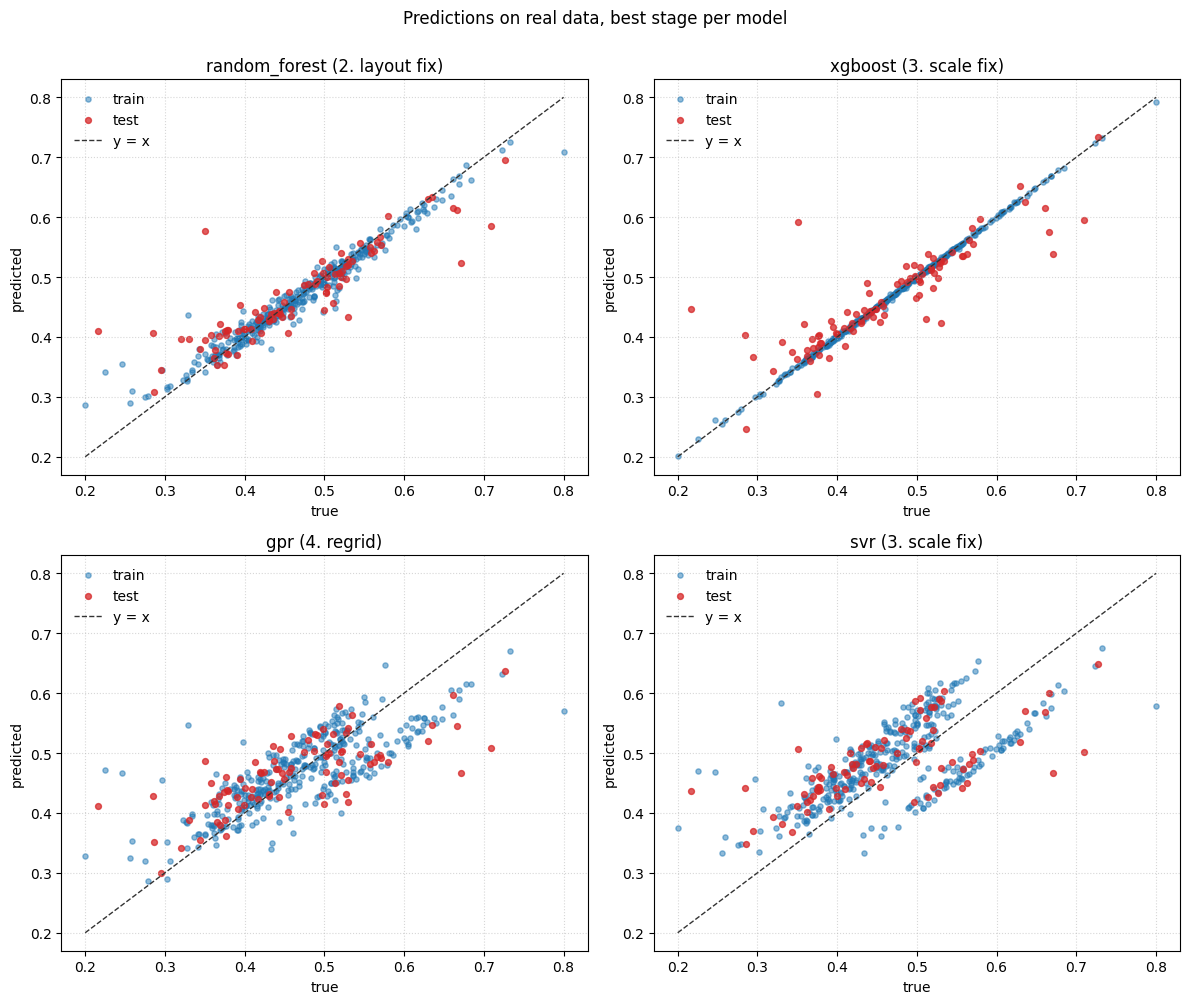

saved reports\figures\real_predictions.png


In [7]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

train.SEED
for ax, (_, row) in zip(axes, best_stage_per_model.iterrows()):
    model_name = row['model']
    stage_name = row['stage']
    est = fitted_real[(model_name, stage_name)]

    X_raw = X_orig  if row['layout'] == 'original' else X_fixed
    y_raw = y_orig  if row['layout'] == 'original' else y_fixed

    train_idx, test_idx = train._split_indices(len(X_raw))
    if row['scale_strategy'] == 'original':
        X_tr, X_te, y_tr, y_te, _ = train._scale_original(
            X_raw, y_raw, train_idx, test_idx
        )
    else:
        X_tr, X_te, y_tr, y_te, _ = train._scale_principled(
            X_raw, y_raw, train_idx, test_idx
        )

    viz.plot_predictions(
        y_tr, est.predict(X_tr),
        y_te, est.predict(X_te),
        title=f'{model_name} ({stage_name})',
        ax=ax,
    )

fig.suptitle('Predictions on real data, best stage per model', y=1.00)
fig.tight_layout()
p = viz.save_figure(fig, 'real_predictions')
plt.show()
print('saved', p)

## 6. Takeaways

- On real data, no model beats a horizontal line at any stage. R2 stays near zero or negative across all stages and all four models. That is the honest starting point and it is a property of the data, not the fix.
- The layout fix does show up in the metrics. Stage 2 R2 differs from stage 1 for every model, in the direction of the fix, but the deltas are small because the models have nothing to learn from 450 samples.
- The scaling fix is a small, principled improvement. It removes test set leakage but does not create signal.
- The regrid for SVR and GPR does not rescue R2 on real data either. The miscalibrated grid was a real bug, but it was not the reason the models failed.

Where the four stages make a visible difference is on the synthetic track in notebook 4, where the models have 5,000 samples to fit.

Next: `04_model_training_synthetic.ipynb`, same four stages on the GAN-augmented data, with the target-spread caveat from notebook 2 carried through.
